# OGA Simulations: Class OGA vs. Hazan-Style Updates

This notebook compares Class OGA with a Hazan-style fast-decay update under three settings. The methodological goal is to separate two effects that were previously confounded:

1. the step-size schedule: $1/\sqrt{t}$ versus $1/t$;
2. the loss function: strongly convex quadratic loss versus convex but not strongly convex absolute loss.

The central thesis is not that one method is always better. Hazan's $O(\log T)$ regret bound is stronger than the general Class OGA $O(\sqrt{T})$ bound, but the stronger bound only has explanatory power when the loss is strongly convex and the curvature parameter is calibrated appropriately. Class OGA has a weaker guarantee, but it relies on fewer assumptions.

The term **Hazan-style** is used carefully. The update $\eta_t = 1/(H t)$ is a valid application of Hazan et al. only when the strong convexity assumptions hold and the curvature parameter $H$ is meaningful. Under absolute loss, there is no valid strong convexity parameter $H$, so the same numeric schedule is only an empirical fast-decay schedule.

The notebook keeps two claims separate:

| Claim | Meaning |
|---|---|
| The theorem does not apply | The assumptions are violated, so the theoretical $O(\log T)$ guarantee is unavailable |
| The algorithm performs poorly | The empirical loss or regret is worse in a particular simulation |

The first claim follows automatically when strong convexity is absent. The second claim is data-dependent and must be shown by the simulation.


---
## Setup and Helper Functions

All simulations use the same online protocol. At round $t$, the algorithm predicts with the current $\theta_t$, suffers loss $g_t(\theta_t)$, observes a subgradient, takes a projected gradient step, and clips the iterate to the feasible set $[-r, r]$.

For Class OGA, the $1/\sqrt{t}$ schedule requires a safe Lipschitz constant over the feasible set. For quadratic loss on $[-r,r]$, this notebook uses

$$
L = 2\left(r + \max_t |y_t|\right),
$$

because $|\nabla (\theta-y)^2| = |2(\theta-y)| \le 2(r + \max_t |y_t|)$. For absolute loss, $L=1$.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from IPython.display import display
except Exception:  # Allows the code cells to run as a plain Python script too.
    display = print

pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 140)

C_CLASS = "#2563EB"   # Class OGA
C_HAZAN = "#D97706"   # Hazan-style, theorem-backed when assumptions hold
C_FAST = "#DC2626"    # Hazan-style schedule without guarantee or with loose calibration
C_ABS = "#059669"     # Absolute-loss comparison
C_DATA = "#6B7280"    # Data / reference
C_ORACLE = "#111827"  # Comparator / target

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "#FAFAFA",
    "axes.grid": True,
    "grid.alpha": 0.3,
    "grid.linestyle": "--",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 10.5,
    "axes.titlesize": 12,
    "axes.labelsize": 10.5,
    "legend.fontsize": 9,
    "legend.framealpha": 0.92,
})


def loss_quad(theta, y):
    return (theta - y) ** 2


def grad_quad(theta, y):
    return 2 * (theta - y)


def loss_abs(theta, y):
    return abs(theta - y)


def grad_abs(theta, y):
    if theta > y:
        return 1.0
    elif theta < y:
        return -1.0
    else:
        return 0.0


def safe_lipschitz_constant(y, loss_name, r):
    y = np.asarray(y, dtype=float)
    if loss_name == "quadratic":
        return 2.0 * (r + np.max(np.abs(y)))
    if loss_name == "absolute":
        return 1.0
    raise ValueError("loss_name must be 'quadratic' or 'absolute'")


def best_fixed_comparator(y, loss_name, r):
    y = np.asarray(y, dtype=float)
    if loss_name == "quadratic":
        theta_star = np.mean(y)
    elif loss_name == "absolute":
        theta_star = np.median(y)
    else:
        raise ValueError("loss_name must be 'quadratic' or 'absolute'")
    return float(np.clip(theta_star, -r, r))


def projected_oga(y, loss_fn, grad_fn, step_rule="sqrt", r=10.0, H=2.0, L=None, theta0=0.0, comparator=None):
    """Projected online gradient descent.

    step_rule="sqrt"   uses eta_t = r / (L sqrt(t)); L must be supplied.
    step_rule="linear" uses eta_t = 1 / (H t); this is theorem-backed only under strong convexity.
    The returned theta array is the prediction used at each round before the update.
    """
    y = np.asarray(y, dtype=float)
    if step_rule == "sqrt" and (L is None or L <= 0):
        raise ValueError("Class OGA with step_rule='sqrt' requires a positive Lipschitz constant L.")
    if step_rule == "linear" and (H is None or H <= 0):
        raise ValueError("Hazan-style step_rule='linear' requires a positive H.")

    theta = float(np.clip(theta0, -r, r))
    T = len(y)
    theta_path = np.empty(T)
    theta_after_update = np.empty(T)
    step_sizes = np.empty(T)
    losses = np.empty(T)

    for idx, yy in enumerate(y):
        t = idx + 1
        theta_path[idx] = theta
        losses[idx] = loss_fn(theta, yy)
        grad = grad_fn(theta, yy)

        if step_rule == "sqrt":
            eta = r / (L * np.sqrt(t))
        elif step_rule == "linear":
            eta = 1.0 / (H * t)
        else:
            raise ValueError("step_rule must be 'sqrt' or 'linear'")

        step_sizes[idx] = eta
        theta = float(np.clip(theta - eta * grad, -r, r))
        theta_after_update[idx] = theta

    result = {
        "theta": theta_path,
        "theta_after_update": theta_after_update,
        "step_sizes": step_sizes,
        "losses": losses,
        "cumulative_loss": np.cumsum(losses),
    }

    if comparator is not None:
        best_losses = np.array([loss_fn(comparator, yy) for yy in y], dtype=float)
        result["comparator"] = comparator
        result["best_losses"] = best_losses
        result["cumulative_best_loss"] = np.cumsum(best_losses)
        result["regret"] = result["cumulative_loss"] - result["cumulative_best_loss"]

    return result


def result_row(method, loss, schedule, theorem_status, result):
    return {
        "Method": method,
        "Loss": loss,
        "Step-size schedule": schedule,
        "Theorem status": theorem_status,
        "Comparator theta*": result.get("comparator", np.nan),
        "Final cumulative loss": result["cumulative_loss"][-1],
        "Final regret": result["regret"][-1] if "regret" in result else np.nan,
    }


def rounded(df, digits=4):
    out = df.copy()
    numeric_cols = out.select_dtypes(include=[np.number]).columns
    out[numeric_cols] = out[numeric_cols].round(digits)
    return out


def add_vertical_markers(ax, rounds, color="#9CA3AF", linewidth=0.9, alpha=0.45):
    for x in rounds:
        ax.axvline(x, color=color, linewidth=linewidth, linestyle="--", alpha=alpha)


print("Setup complete.")


Setup complete.


---
## Simulation 1: Quadratic Loss in a Stable Environment

Simulation 1 is Hazan's home territory. Quadratic loss is strongly convex with curvature $H = 2$, so Hazan's $O(\log T)$ theorem applies. The comparison isolates the effect of the step-size rule under valid assumptions.

Both algorithms use the same data sequence, same initial value, same feasible set, and same best fixed comparator.

| Method | Loss | Step size | Theorem valid? |
|---|---|---|---|
| Class OGA | Quadratic | $r/(L\sqrt{t})$ | Yes, general convex theorem |
| Hazan-style | Quadratic | $1/(H t)=1/(2t)$ | Yes, strong convexity theorem |


,Method,Loss,Step-size schedule,Theorem status,Comparator theta*,Final cumulative loss,Final regret
0,Class OGA,Quadratic,r/(L sqrt(t)),General convex OGA theorem applies,2.0534,520.2273,31.7519
1,Hazan-style,Quadratic,1/(2t),Hazan strong-convexity theorem applies,2.0534,510.2623,21.7868


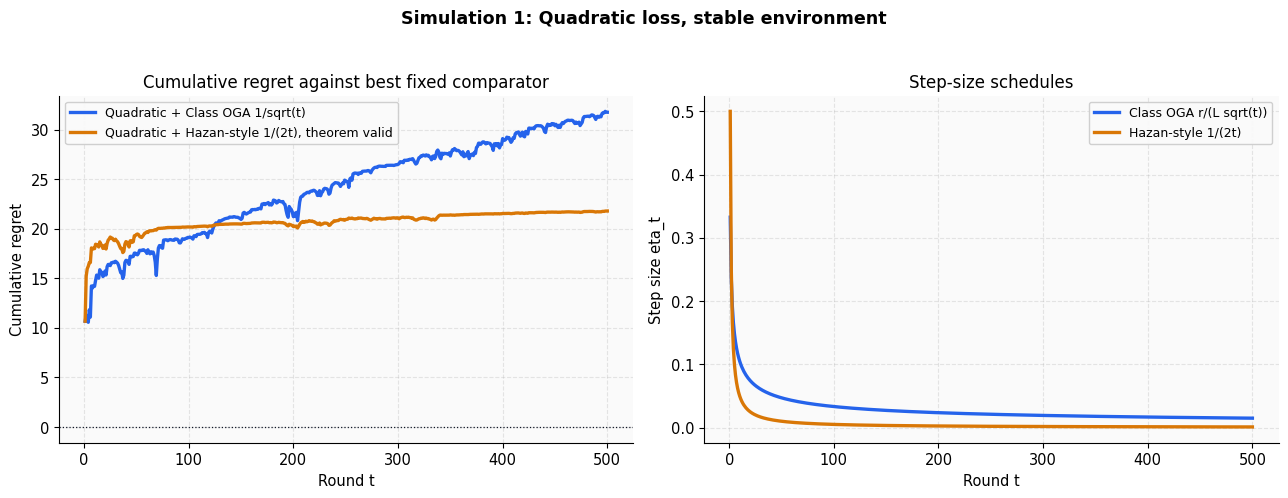

In [2]:
np.random.seed(1)
T1 = 500
r1 = 10.0
H_quad = 2.0
ns1 = np.arange(1, T1 + 1)

# Stable strongly convex setting: the same data sequence is used for both methods.
y_stable = np.random.normal(2.0, 1.0, T1)
L_quad_1 = safe_lipschitz_constant(y_stable, "quadratic", r1)
theta_star_quad_1 = best_fixed_comparator(y_stable, "quadratic", r1)

class_oga_1 = projected_oga(
    y_stable, loss_quad, grad_quad,
    step_rule="sqrt", r=r1, L=L_quad_1, comparator=theta_star_quad_1
)

hazan_1 = projected_oga(
    y_stable, loss_quad, grad_quad,
    step_rule="linear", r=r1, H=H_quad, comparator=theta_star_quad_1
)

sim1_table = pd.DataFrame([
    result_row("Class OGA", "Quadratic", "r/(L sqrt(t))", "General convex OGA theorem applies", class_oga_1),
    result_row("Hazan-style", "Quadratic", "1/(2t)", "Hazan strong-convexity theorem applies", hazan_1),
])

display(rounded(sim1_table, 4))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
fig.suptitle("Simulation 1: Quadratic loss, stable environment", fontweight="bold", y=1.03)

ax = axes[0]
ax.plot(ns1, class_oga_1["regret"], color=C_CLASS, linewidth=2.4, label="Quadratic + Class OGA 1/sqrt(t)")
ax.plot(ns1, hazan_1["regret"], color=C_HAZAN, linewidth=2.4, label="Quadratic + Hazan-style 1/(2t), theorem valid")
ax.axhline(0, color="#111827", linewidth=0.9, linestyle=":")
ax.set_title("Cumulative regret against best fixed comparator")
ax.set_xlabel("Round t")
ax.set_ylabel("Cumulative regret")
ax.legend()

ax = axes[1]
ax.plot(ns1, class_oga_1["step_sizes"], color=C_CLASS, linewidth=2.4, label="Class OGA r/(L sqrt(t))")
ax.plot(ns1, hazan_1["step_sizes"], color=C_HAZAN, linewidth=2.4, label="Hazan-style 1/(2t)")
ax.set_title("Step-size schedules")
ax.set_xlabel("Round t")
ax.set_ylabel("Step size eta_t")
ax.legend()

plt.tight_layout()
plt.show()


### Simulation 1 Interpretation

Quadratic loss satisfies the strong convexity assumption with $H=2$, so the Hazan-style $1/(2t)$ update is theorem-backed in this simulation. If the final regret table shows lower regret for that schedule, the result is consistent with the theoretical intuition behind the stronger $O(\log T)$ guarantee. A finite simulation does not prove an asymptotic rate; it shows a result that is theoretically interpretable because the assumptions hold.


---
## Simulation 2: Spike Data with a 2x2 Factorial Design

Simulation 2 fixes the original methodological issue by using one common spike sequence for all four cells. This separates the step-size effect from the loss-function effect.

| Loss function | Class OGA step size $1/\sqrt{t}$ | Hazan-style step size $1/t$ |
|---|---|---|
| Quadratic loss | Cell 1 | Cell 2 |
| Absolute loss | Cell 3 | Cell 4 |

The important distinction is that Cell 4 is **not** a valid application of Hazan's theorem. It is only the empirical schedule $1/(2t)$ applied to absolute loss, with no strong-convexity guarantee.

The comparison uses the theoretically calibrated versions of the two step-size rules. Therefore, the difference reflects both the decay pattern and the scaling constants implied by each theoretical framework. A pure comparison of decay rates alone would require matching or tuning the initial step-size constants separately.


,Method,Loss,Step-size schedule,Theorem status,Comparator theta*,Final cumulative loss,Final regret
0,Cell 1: Class OGA,Quadratic,r/(L sqrt(t)),General convex OGA theorem applies,0.1425,761.1456,19.7528
1,Cell 2: Hazan-style,Quadratic,1/(2t),Hazan strong-convexity theorem applies,0.1425,748.9892,7.5964
2,Cell 3: Class OGA,Absolute,r/(1 sqrt(t)),General convex OGA theorem applies,0.0680,465.3279,118.2142
3,Cell 4: Fast-decay schedule,Absolute,1/(2t),No Hazan theorem guarantee,0.0680,350.3836,3.2698


,Loss and schedule,Mean loss on non-spike rounds,Mean loss on spike rounds,Spike/non-spike loss ratio
0,Quadratic + Class OGA 1/sqrt(t),0.9771,62.6916,64.1577
1,Absolute + Class OGA 1/sqrt(t),1.0631,7.7423,7.2825


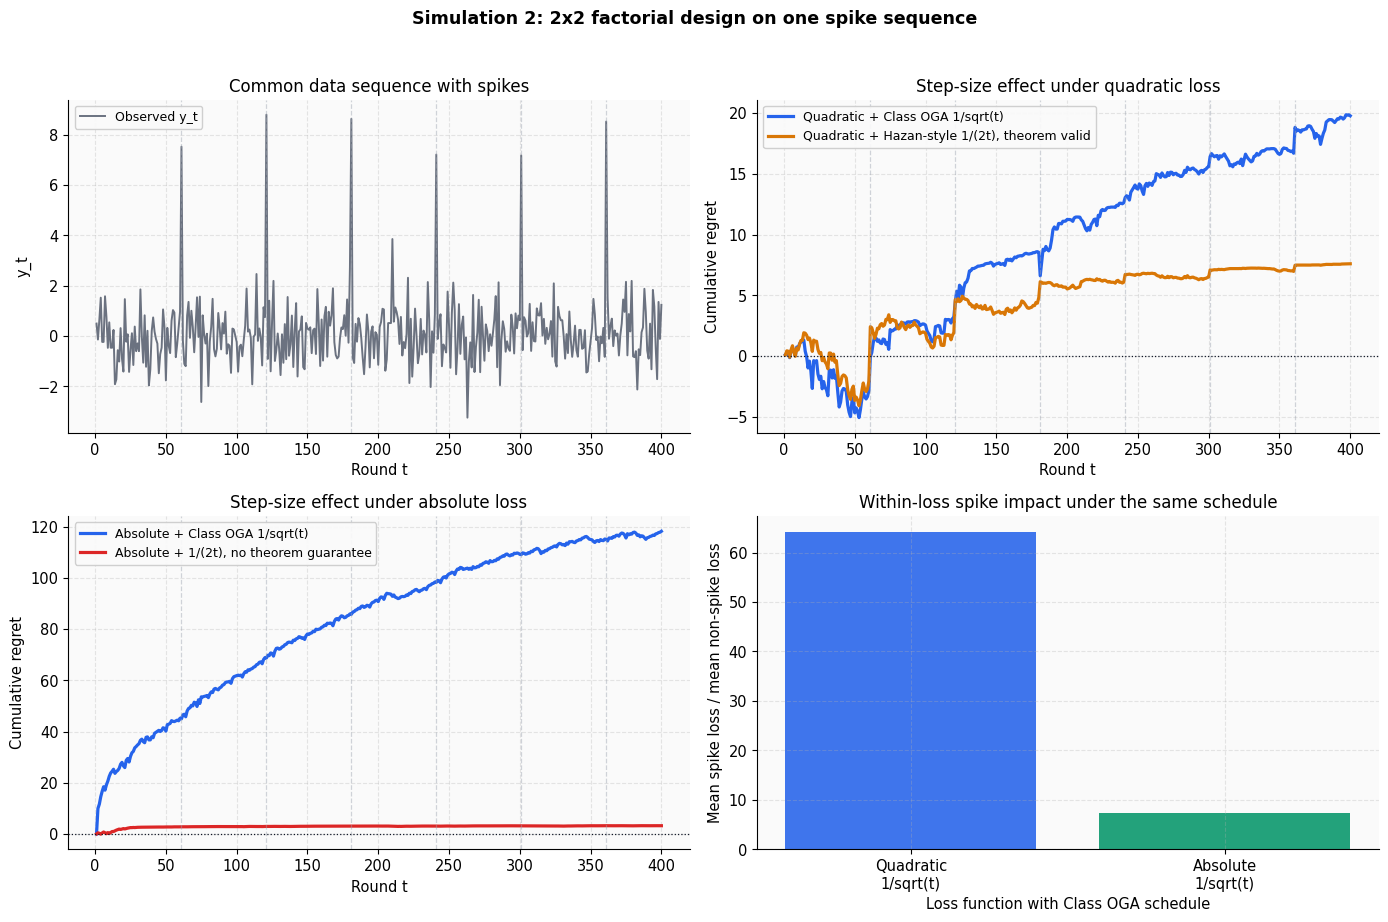

In [3]:
np.random.seed(42)
T2 = 400
r2 = 10.0
ns2 = np.arange(1, T2 + 1)

base = np.random.normal(0, 1.0, T2)
spike_indices = [60, 120, 180, 240, 300, 360]
y_spike = base.copy()
y_spike[spike_indices] += 8.0
spike_rounds = [idx + 1 for idx in spike_indices]
spike_mask = np.zeros(T2, dtype=bool)
spike_mask[spike_indices] = True

L_quad_2 = safe_lipschitz_constant(y_spike, "quadratic", r2)
L_abs_2 = safe_lipschitz_constant(y_spike, "absolute", r2)
theta_star_quad_2 = best_fixed_comparator(y_spike, "quadratic", r2)
theta_star_abs_2 = best_fixed_comparator(y_spike, "absolute", r2)

quad_sqrt = projected_oga(
    y_spike, loss_quad, grad_quad,
    step_rule="sqrt", r=r2, L=L_quad_2, comparator=theta_star_quad_2
)

quad_linear = projected_oga(
    y_spike, loss_quad, grad_quad,
    step_rule="linear", r=r2, H=2.0, comparator=theta_star_quad_2
)

abs_sqrt = projected_oga(
    y_spike, loss_abs, grad_abs,
    step_rule="sqrt", r=r2, L=L_abs_2, comparator=theta_star_abs_2
)

abs_linear = projected_oga(
    y_spike, loss_abs, grad_abs,
    step_rule="linear", r=r2, H=2.0, comparator=theta_star_abs_2
)

sim2_table = pd.DataFrame([
    result_row("Cell 1: Class OGA", "Quadratic", "r/(L sqrt(t))", "General convex OGA theorem applies", quad_sqrt),
    result_row("Cell 2: Hazan-style", "Quadratic", "1/(2t)", "Hazan strong-convexity theorem applies", quad_linear),
    result_row("Cell 3: Class OGA", "Absolute", "r/(1 sqrt(t))", "General convex OGA theorem applies", abs_sqrt),
    result_row("Cell 4: Fast-decay schedule", "Absolute", "1/(2t)", "No Hazan theorem guarantee", abs_linear),
])

display(rounded(sim2_table, 4))

spike_impact_table = pd.DataFrame([
    {
        "Loss and schedule": "Quadratic + Class OGA 1/sqrt(t)",
        "Mean loss on non-spike rounds": quad_sqrt["losses"][~spike_mask].mean(),
        "Mean loss on spike rounds": quad_sqrt["losses"][spike_mask].mean(),
        "Spike/non-spike loss ratio": quad_sqrt["losses"][spike_mask].mean() / quad_sqrt["losses"][~spike_mask].mean(),
    },
    {
        "Loss and schedule": "Absolute + Class OGA 1/sqrt(t)",
        "Mean loss on non-spike rounds": abs_sqrt["losses"][~spike_mask].mean(),
        "Mean loss on spike rounds": abs_sqrt["losses"][spike_mask].mean(),
        "Spike/non-spike loss ratio": abs_sqrt["losses"][spike_mask].mean() / abs_sqrt["losses"][~spike_mask].mean(),
    },
])

display(rounded(spike_impact_table, 4))

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle("Simulation 2: 2x2 factorial design on one spike sequence", fontweight="bold", y=1.02)

ax = axes[0, 0]
ax.plot(ns2, y_spike, color=C_DATA, linewidth=1.4, label="Observed y_t")
add_vertical_markers(ax, spike_rounds)
ax.set_title("Common data sequence with spikes")
ax.set_xlabel("Round t")
ax.set_ylabel("y_t")
ax.legend()

ax = axes[0, 1]
ax.plot(ns2, quad_sqrt["regret"], color=C_CLASS, linewidth=2.3, label="Quadratic + Class OGA 1/sqrt(t)")
ax.plot(ns2, quad_linear["regret"], color=C_HAZAN, linewidth=2.3, label="Quadratic + Hazan-style 1/(2t), theorem valid")
add_vertical_markers(ax, spike_rounds)
ax.axhline(0, color="#111827", linewidth=0.9, linestyle=":")
ax.set_title("Step-size effect under quadratic loss")
ax.set_xlabel("Round t")
ax.set_ylabel("Cumulative regret")
ax.legend()

ax = axes[1, 0]
ax.plot(ns2, abs_sqrt["regret"], color=C_CLASS, linewidth=2.3, label="Absolute + Class OGA 1/sqrt(t)")
ax.plot(ns2, abs_linear["regret"], color=C_FAST, linewidth=2.3, label="Absolute + 1/(2t), no theorem guarantee")
add_vertical_markers(ax, spike_rounds)
ax.axhline(0, color="#111827", linewidth=0.9, linestyle=":")
ax.set_title("Step-size effect under absolute loss")
ax.set_xlabel("Round t")
ax.set_ylabel("Cumulative regret")
ax.legend()

ax = axes[1, 1]
ax.bar(
    ["Quadratic\n1/sqrt(t)", "Absolute\n1/sqrt(t)"],
    spike_impact_table["Spike/non-spike loss ratio"],
    color=[C_CLASS, C_ABS],
    alpha=0.88,
)
ax.set_title("Within-loss spike impact under the same schedule")
ax.set_ylabel("Mean spike loss / mean non-spike loss")
ax.set_xlabel("Loss function with Class OGA schedule")

plt.tight_layout()
plt.show()


### Simulation 2 Interpretation

- **Step-size effect under quadratic loss:** Cell 1 vs. Cell 2 compares Class OGA $1/\sqrt{t}$ with Hazan-style $1/t$ while the strong-convexity assumptions hold.
- **Step-size effect under absolute loss:** Cell 3 vs. Cell 4 compares the same two step-size families when strong convexity is absent.
- **Loss-function effect under Class OGA scaling:** Cell 1 vs. Cell 3 changes the loss while holding the $1/\sqrt{t}$ step-size family fixed.
- **Loss-function effect under fast-decay scaling:** Cell 2 vs. Cell 4 changes the loss while holding the $1/t$ step-size family fixed, but the Hazan theorem only explains the quadratic cell.

Because quadratic and absolute losses have different scales, raw regret magnitudes across those two losses should not be treated as the same unit. The spike-impact ratio is normalized within each loss function. Absolute loss mechanically reduces the penalty from spikes because errors enter linearly rather than quadratically; that is a property of the loss function, not evidence that one step-size theorem dominates the other.

The absolute-loss cells are not valid applications of Hazan's theorem, because absolute loss is not strongly convex. Therefore, the $O(\log T)$ guarantee no longer applies. However, this does not imply that the $1/(2t)$ schedule must perform poorly empirically. In this particular spike dataset, it may still perform well because the signal is mostly stable and absolute loss mechanically limits the penalty from outliers. The correct lesson is that once strong convexity is removed, performance becomes data-dependent and is no longer guaranteed by the theorem.


---
## Simulation 3: True Regime Shift with Adaptation Metrics

Simulation 3 uses quadratic loss for all methods, so the loss function is controlled. The data-generating process changes halfway through: the phase-1 optimizer is near $-4$, and the phase-2 optimizer is near $4$.

This setting tests adaptation after a structural break. Total static regret against one fixed comparator is reported, but it is not sufficient by itself because the best fixed value over the whole sample does not represent either phase well. The adaptation table therefore also reports post-shift loss, post-shift regret against the phase-2 oracle, and mean distance to the phase-2 target.

| Method | Loss | Step size | Purpose |
|---|---|---|---|
| Class OGA | Quadratic | $r/(L\sqrt{t})$ | General convex baseline |
| Hazan correct $H$ | Quadratic | $1/(2t)$ | Valid strong-convexity schedule |
| Hazan loose $H$ | Quadratic | $1/(0.1t)$ | Sensitivity to loose curvature calibration and aggressive step sizes |


,Method,Loss,Step-size schedule,Theorem status,Comparator theta*,Final cumulative loss,Final regret
0,Class OGA,Quadratic,r/(L sqrt(t)),General convex OGA theorem applies,-0.0553,1292.6253,-5312.6757
1,Hazan correct H,Quadratic,1/(2t),Hazan strong-convexity theorem applies,-0.0553,6663.5529,58.2519
2,Hazan loose H,Quadratic,1/(0.1t),Loose valid curvature lower bound; aggressive ...,-0.0553,1777.3286,-4827.9723


,Method,Post-shift cumulative loss,Post-shift average loss,Post-shift regret vs phase-2 oracle,Mean post-shift distance to phase-2 target,Prediction after final update
0,Class OGA,1033.0231,5.1651,861.5824,1.0355,3.8262
1,"Hazan-style 1/(2t), theorem valid",6407.8247,32.0391,6236.3840,5.4630,-0.0553
2,"Hazan-style 1/(0.1t), loose H",568.2035,2.8410,396.7628,0.5126,3.8364


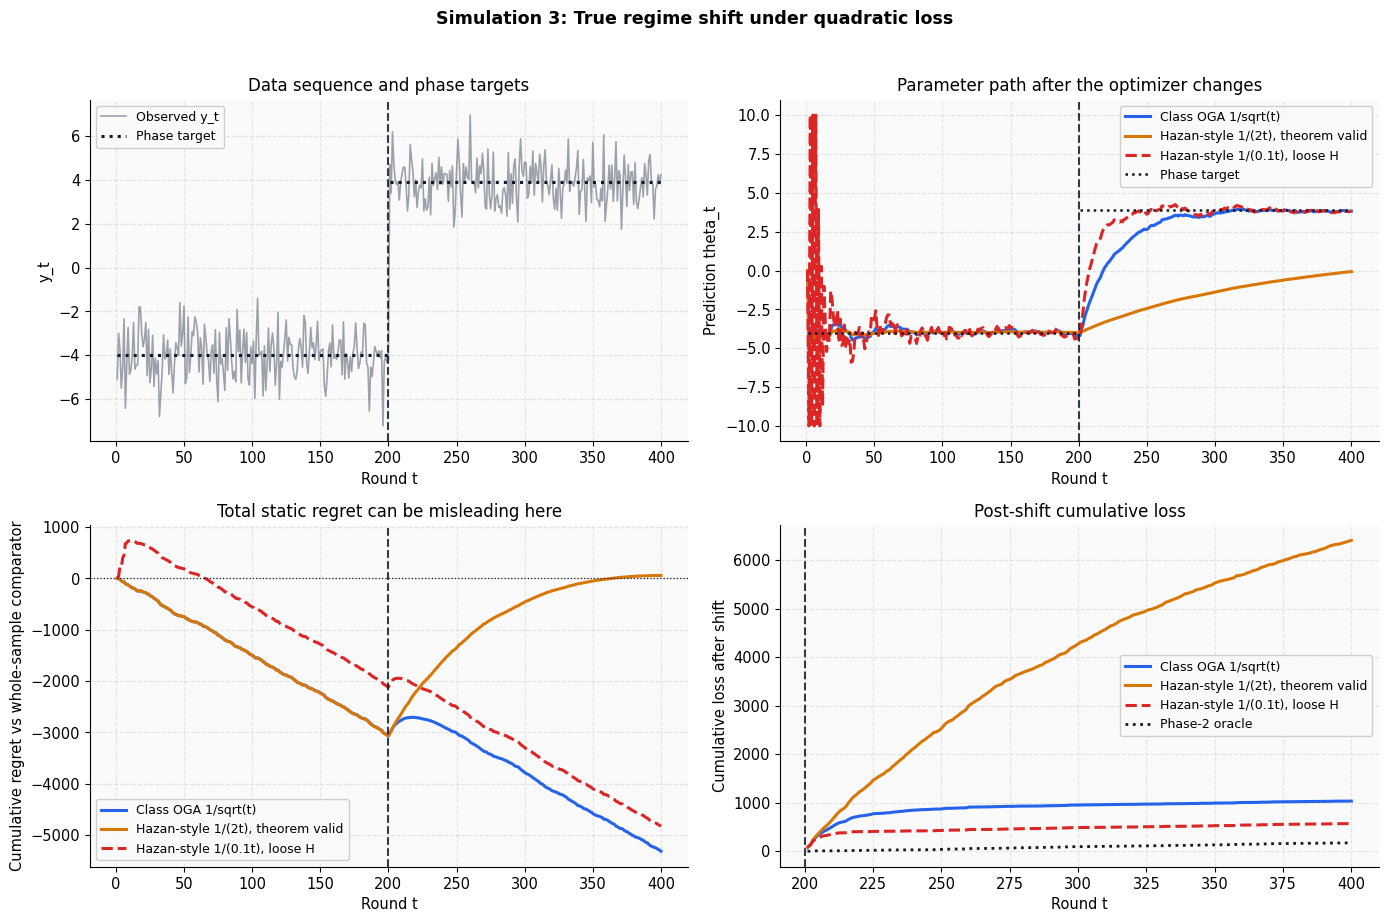

Class OGA step size at the shift: 0.02052
Hazan-style 1/(2t) step size at the shift: 0.00250
Hazan-style 1/(0.1t) loose-H step size at the shift: 0.05000


In [4]:
np.random.seed(123)
T3 = 400
split = 200
r3 = 10.0
ns3 = np.arange(1, T3 + 1)

# True optimizer shift: the phase means are different.
y_phase1 = np.random.normal(-4, 1.0, split)
y_phase2 = np.random.normal(4, 1.0, T3 - split)
y_shift = np.concatenate([y_phase1, y_phase2])

L_quad_3 = safe_lipschitz_constant(y_shift, "quadratic", r3)
theta_star_total_3 = best_fixed_comparator(y_shift, "quadratic", r3)
theta_star_phase1_3 = best_fixed_comparator(y_phase1, "quadratic", r3)
theta_star_phase2_3 = best_fixed_comparator(y_phase2, "quadratic", r3)

class_oga_shift = projected_oga(
    y_shift, loss_quad, grad_quad,
    step_rule="sqrt", r=r3, L=L_quad_3, comparator=theta_star_total_3
)

hazan_correct_shift = projected_oga(
    y_shift, loss_quad, grad_quad,
    step_rule="linear", r=r3, H=2.0, comparator=theta_star_total_3
)

hazan_loose_shift = projected_oga(
    y_shift, loss_quad, grad_quad,
    step_rule="linear", r=r3, H=0.1, comparator=theta_star_total_3
)

sim3_methods = {
    "Class OGA": class_oga_shift,
    "Hazan-style 1/(2t), theorem valid": hazan_correct_shift,
    "Hazan-style 1/(0.1t), loose H": hazan_loose_shift,
}

sim3_total_table = pd.DataFrame([
    result_row("Class OGA", "Quadratic", "r/(L sqrt(t))", "General convex OGA theorem applies", class_oga_shift),
    result_row("Hazan correct H", "Quadratic", "1/(2t)", "Hazan strong-convexity theorem applies", hazan_correct_shift),
    result_row("Hazan loose H", "Quadratic", "1/(0.1t)", "Loose valid curvature lower bound; aggressive step size", hazan_loose_shift),
])

display(rounded(sim3_total_table, 4))

phase2_best_losses = np.array([loss_quad(theta_star_phase2_3, yy) for yy in y_shift[split:]], dtype=float)
phase2_best_total_loss = phase2_best_losses.sum()

adaptation_rows = []
for method, result in sim3_methods.items():
    post_losses = result["losses"][split:]
    post_theta = result["theta"][split:]
    adaptation_rows.append({
        "Method": method,
        "Post-shift cumulative loss": post_losses.sum(),
        "Post-shift average loss": post_losses.mean(),
        "Post-shift regret vs phase-2 oracle": post_losses.sum() - phase2_best_total_loss,
        "Mean post-shift distance to phase-2 target": np.mean(np.abs(post_theta - theta_star_phase2_3)),
        "Prediction after final update": result["theta_after_update"][-1],
    })

sim3_adaptation_table = pd.DataFrame(adaptation_rows)
display(rounded(sim3_adaptation_table, 4))


def mark_shift(ax):
    ax.axvline(split, color=C_ORACLE, linewidth=1.5, linestyle="--", alpha=0.85, label="Shift round" if not ax.get_legend_handles_labels()[1] else None)

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle("Simulation 3: True regime shift under quadratic loss", fontweight="bold", y=1.02)

ax = axes[0, 0]
ax.plot(ns3, y_shift, color=C_DATA, linewidth=1.2, alpha=0.65, label="Observed y_t")
ax.hlines(theta_star_phase1_3, 1, split, color=C_ORACLE, linewidth=2.2, linestyle=":", label="Phase target")
ax.hlines(theta_star_phase2_3, split + 1, T3, color=C_ORACLE, linewidth=2.2, linestyle=":")
mark_shift(ax)
ax.set_title("Data sequence and phase targets")
ax.set_xlabel("Round t")
ax.set_ylabel("y_t")
ax.legend()

ax = axes[0, 1]
ax.plot(ns3, class_oga_shift["theta"], color=C_CLASS, linewidth=2.2, label="Class OGA 1/sqrt(t)")
ax.plot(ns3, hazan_correct_shift["theta"], color=C_HAZAN, linewidth=2.2, label="Hazan-style 1/(2t), theorem valid")
ax.plot(ns3, hazan_loose_shift["theta"], color=C_FAST, linewidth=2.2, linestyle="--", label="Hazan-style 1/(0.1t), loose H")
ax.hlines(theta_star_phase1_3, 1, split, color=C_ORACLE, linewidth=1.8, linestyle=":", label="Phase target")
ax.hlines(theta_star_phase2_3, split + 1, T3, color=C_ORACLE, linewidth=1.8, linestyle=":")
mark_shift(ax)
ax.set_title("Parameter path after the optimizer changes")
ax.set_xlabel("Round t")
ax.set_ylabel("Prediction theta_t")
ax.legend()

ax = axes[1, 0]
ax.plot(ns3, class_oga_shift["regret"], color=C_CLASS, linewidth=2.2, label="Class OGA 1/sqrt(t)")
ax.plot(ns3, hazan_correct_shift["regret"], color=C_HAZAN, linewidth=2.2, label="Hazan-style 1/(2t), theorem valid")
ax.plot(ns3, hazan_loose_shift["regret"], color=C_FAST, linewidth=2.2, linestyle="--", label="Hazan-style 1/(0.1t), loose H")
mark_shift(ax)
ax.axhline(0, color=C_ORACLE, linewidth=0.9, linestyle=":")
ax.set_title("Total static regret can be misleading here")
ax.set_xlabel("Round t")
ax.set_ylabel("Cumulative regret vs whole-sample comparator")
ax.legend()

ax = axes[1, 1]
post_rounds = ns3[split:]
ax.plot(post_rounds, np.cumsum(class_oga_shift["losses"][split:]), color=C_CLASS, linewidth=2.2, label="Class OGA 1/sqrt(t)")
ax.plot(post_rounds, np.cumsum(hazan_correct_shift["losses"][split:]), color=C_HAZAN, linewidth=2.2, label="Hazan-style 1/(2t), theorem valid")
ax.plot(post_rounds, np.cumsum(hazan_loose_shift["losses"][split:]), color=C_FAST, linewidth=2.2, linestyle="--", label="Hazan-style 1/(0.1t), loose H")
ax.plot(post_rounds, np.cumsum(phase2_best_losses), color=C_ORACLE, linewidth=2.0, linestyle=":", label="Phase-2 oracle")
ax.axvline(split, color=C_ORACLE, linewidth=1.5, linestyle="--", alpha=0.85)
ax.set_title("Post-shift cumulative loss")
ax.set_xlabel("Round t")
ax.set_ylabel("Cumulative loss after shift")
ax.legend()

plt.tight_layout()
plt.show()

print(f"Class OGA step size at the shift: {class_oga_shift['step_sizes'][split - 1]:.5f}")
print(f"Hazan-style 1/(2t) step size at the shift: {hazan_correct_shift['step_sizes'][split - 1]:.5f}")
print(f"Hazan-style 1/(0.1t) loose-H step size at the shift: {hazan_loose_shift['step_sizes'][split - 1]:.5f}")


### Simulation 3 Interpretation

Simulation 3 uses the same quadratic loss for all methods, so the loss function is controlled. The change is in the data-generating process: the optimizer moves from the phase-1 mean to the phase-2 mean. This tests adaptation after a structural break. The fast-decaying $1/t$ schedule may become less flexible after many rounds, while the $1/\sqrt{t}$ schedule retains a larger step size and may adapt more safely.

Hazan's theorem is a static regret guarantee under strongly convex losses. In a regime-shift setting, static regret may not be the right metric to evaluate adaptation because the relevant target changes over time. Static regret compares every method with the best single fixed comparator over the whole horizon; in a two-regime environment, that comparator may not represent the desired moving target. Therefore, post-shift adaptation metrics are more informative than total static regret alone, even when total static regret is negative or otherwise counterintuitive.

The $H=0.1$ case is best interpreted as loose curvature calibration. Since the true quadratic curvature is $2$, $0.1$ is still a valid lower bound, but it produces a much larger $1/(Ht)$ step size and a looser theoretical bound. It is included to show sensitivity to the curvature constant, not to claim that the theorem is invalid for quadratic loss.


---
## Summary

| Simulation | Loss | Data structure | Hazan theorem valid? | Main lesson |
|---|---|---|---|---|
| 1 | Quadratic | Stable | Yes | Hazan's $1/(Ht)$ schedule is theoretically justified under strong convexity |
| 2, Cells 1 vs 2 | Quadratic | Spikes | Yes | Step-size effect can be studied cleanly under strong convexity |
| 2, Cells 3 vs 4 | Absolute | Spikes | No | Hazan's theorem does not apply; empirical performance is data-dependent |
| 2, Cells 1 vs 3 and 2 vs 4 | Different losses | Spikes | Mixed | Absolute loss mechanically reduces spike penalties, but raw regrets across losses have different scales |
| 3 | Quadratic | True regime shift | Yes for static regret; adaptation is a different criterion | Fast-decaying step sizes may adapt slowly after structural breaks |

The main lesson is not that one algorithm always dominates the other. Hazan's $O(\log T)$ bound is stronger, but it is meaningful only when the strong convexity assumption and curvature calibration are appropriate. Class OGA has a weaker $O(\sqrt{T})$ bound, but it requires fewer assumptions and remains applicable in broader convex settings.

Therefore, the practical conclusion is: check the assumptions before choosing the algorithm. A better theoretical bound is useful only when the problem actually satisfies the assumptions behind that bound.

- **Simulation 1:** When strong convexity holds, the Hazan-style $1/t$ update has theoretical support and can achieve lower regret.
- **Simulation 2:** The 2x2 design separates step-size effects from loss-function effects; outside strong convexity, Hazan's guarantee disappears even if the $1/t$ schedule works empirically.
- **Simulation 3:** Under regime shifts, static regret is not enough to evaluate adaptation; fast-decaying schedules may become less flexible after the target changes.

The main lesson is that regret bounds are conditional tools: they are powerful when their assumptions match the problem, but misleading if applied outside those assumptions.
